# Model 1A, CatBoost Experiment 04: Airport-wide and Same-Airline W60 Backlog

This append-only experiment tests whether same-airline operational pressure adds information beyond CatBoost Experiment 02's airport-wide backlog and full-history rotation state. The control is the exact 20-field raw baseline, 13 full-history rotation fields with the 24-hour long-turn mask, and three compact airport-wide W60 fields. The expanded variant adds five predeclared same-airline W60 fields: pending count, completed count, mean signed delay, delay rate, and pending share.

CatBoost Experiment 02's classifier remains fixed at depth 6, learning rate 0.03, L2 leaf regularization 3, no class weighting, and 683 trees. Five expanding chronological folds within 2019 select the feature variant and operating threshold. Both variants are fitted on all 2019 rows and compared once on 2023. The three existing feature paths are paired in memory; no combined dataset is written and 2024 is never loaded. The final-tail assignment caveat remains unchanged.


In [1]:
from pathlib import Path
from time import perf_counter

import catboost
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, average_precision_score,
    balanced_accuracy_score, brier_score_loss, f1_score,
    matthews_corrcoef, precision_recall_curve, precision_score,
    recall_score, roc_auc_score, roc_curve,
)

AIRPORT = "JFK"
TRAIN_YEAR = 2019
VALIDATION_YEAR = 2023
TARGET = "DepDel15"
BACKLOG_WINDOW_MINUTES = 60
LONG_TURN_HOURS = 24
RANDOM_STATE = 42
N_TIME_SPLITS = 5

# Fixed CatBoost Experiment 02 configuration.
FIXED_ITERATIONS = 683
FIXED_DEPTH = 6
FIXED_LEARNING_RATE = 0.03
FIXED_L2_LEAF_REG = 3
N_JOBS = 4

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
print(f"CatBoost {catboost.__version__}")


CatBoost 1.2.10


This notebook is intentionally a controlled feature experiment rather than another classifier search. Holding CatBoost 02 fixed isolates whether airline-specific pressure adds information after the model already knows airport-wide W60 pressure and aircraft-rotation state.


## Pair and validate the three established feature paths

Full-history rotation, airport-wide W60 backlog, and same-airline W60 backlog files are loaded separately and paired only after strict three-way row-identity checks. The notebook does not write a combined feature dataset.


In [2]:
def find_project_root(start: Path) -> Path:
    required = [
        Path("data/features") / f"{AIRPORT}_{year}_departures_{kind}.csv"
        for year in (TRAIN_YEAR, VALIDATION_YEAR)
        for kind in (
            "rotation_full_history",
            f"backlog_w{BACKLOG_WINDOW_MINUTES}",
            f"backlog_airline_w{BACKLOG_WINDOW_MINUTES}",
        )
    ]
    for candidate in (start, *start.parents):
        if all((candidate / path).is_file() for path in required):
            return candidate
    raise FileNotFoundError(f"Could not locate required experiment files: {required}")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
rotation_frames, backlog_frames, airline_backlog_frames = {}, {}, {}
for partition, year in [("training", TRAIN_YEAR), ("validation", VALIDATION_YEAR)]:
    feature_dir = PROJECT_ROOT / "data/features"
    rotation_path = feature_dir / f"{AIRPORT}_{year}_departures_rotation_full_history.csv"
    backlog_path = feature_dir / f"{AIRPORT}_{year}_departures_backlog_w{BACKLOG_WINDOW_MINUTES}.csv"
    airline_path = feature_dir / f"{AIRPORT}_{year}_departures_backlog_airline_w{BACKLOG_WINDOW_MINUTES}.csv"
    rotation_frames[partition] = pd.read_csv(rotation_path, low_memory=False)
    backlog_frames[partition] = pd.read_csv(backlog_path, low_memory=False)
    airline_backlog_frames[partition] = pd.read_csv(airline_path, low_memory=False)
    print(f"{partition:10s}: {len(rotation_frames[partition]):,} rotation rows <- {rotation_path.name}")
    print(f"{'':10s}  {len(backlog_frames[partition]):,} airport backlog rows <- {backlog_path.name}")
    print(f"{'':10s}  {len(airline_backlog_frames[partition]):,} airline backlog rows <- {airline_path.name}")


training  : 107,430 rotation rows <- JFK_2019_departures_rotation_full_history.csv
            107,430 airport backlog rows <- JFK_2019_departures_backlog_w60.csv
            107,430 airline backlog rows <- JFK_2019_departures_backlog_airline_w60.csv


validation: 109,983 rotation rows <- JFK_2023_departures_rotation_full_history.csv
            109,983 airport backlog rows <- JFK_2023_departures_backlog_w60.csv
            109,983 airline backlog rows <- JFK_2023_departures_backlog_airline_w60.csv


In [3]:
ROTATION_FEATURES = [
    "ROTATION_STATUS", "ROTATION_MATCH_FOUND", "ROTATION_INBOUND_ORIGIN",
    "ROTATION_SCHEDULED_TURN_MINUTES",
    "ROTATION_INBOUND_ARRIVED_BY_CUTOFF",
    "ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF",
    "ROTATION_INBOUND_OVERDUE_MINUTES",
    "ROTATION_LOG_INBOUND_OVERDUE_MINUTES",
    "ROTATION_ACTUAL_TURN_MINUTES", "ROTATION_LOG_ACTUAL_TURN_MINUTES",
    "ROTATION_INBOUND_ARR_DELAY", "ROTATION_INBOUND_DELAYED_15",
    "ROTATION_LOG_SCHEDULED_TURN_MINUTES",
]
ROTATION_AUDIT_COLUMNS = [
    "ROTATION_TARGET_CUTOFF_UTC", "ROTATION_PRIOR_REPORTING_AIRLINE",
    "ROTATION_PRIOR_FLIGHT_NUMBER", "ROTATION_PRIOR_FLIGHT_DATE",
    "ROTATION_PRIOR_SCHEDULED_DEPARTURE_UTC",
    "ROTATION_PRIOR_SCHEDULED_ARRIVAL_UTC",
    "ROTATION_PRIOR_ACTUAL_ARRIVAL_UTC",
    "ROTATION_SCHEDULE_RECONSTRUCTION_ERROR_MINUTES",
]
BACKLOG_PREFIX = f"BACKLOG_W{BACKLOG_WINDOW_MINUTES}"
FULL_BACKLOG_FEATURES = [
    f"{BACKLOG_PREFIX}_SCHEDULED_COUNT", f"{BACKLOG_PREFIX}_COMPLETED_COUNT",
    f"{BACKLOG_PREFIX}_PENDING_COUNT", f"{BACKLOG_PREFIX}_DELAYED_DEPARTURE_COUNT",
    f"{BACKLOG_PREFIX}_DELAY_RATE", f"{BACKLOG_PREFIX}_MEAN_DEP_DELAY",
    f"{BACKLOG_PREFIX}_MEAN_DEP_DELAY_MINUTES",
    f"{BACKLOG_PREFIX}_TOTAL_DEP_DELAY_MINUTES",
]
COMPACT_BACKLOG_FEATURES = [
    f"{BACKLOG_PREFIX}_PENDING_COUNT", f"{BACKLOG_PREFIX}_COMPLETED_COUNT",
    f"{BACKLOG_PREFIX}_MEAN_DEP_DELAY",
]
AIRLINE_BACKLOG_PREFIX = f"AIRLINE_BACKLOG_W{BACKLOG_WINDOW_MINUTES}"
FULL_AIRLINE_BACKLOG_FEATURES = [
    f"{AIRLINE_BACKLOG_PREFIX}_SCHEDULED_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_COMPLETED_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_PENDING_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_DELAYED_DEPARTURE_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_DELAY_RATE",
    f"{AIRLINE_BACKLOG_PREFIX}_MEAN_DEP_DELAY",
    f"{AIRLINE_BACKLOG_PREFIX}_MEAN_DEP_DELAY_MINUTES",
    f"{AIRLINE_BACKLOG_PREFIX}_TOTAL_DEP_DELAY_MINUTES",
    f"{AIRLINE_BACKLOG_PREFIX}_PENDING_SHARE",
]
SELECTED_AIRLINE_BACKLOG_FEATURES = [
    f"{AIRLINE_BACKLOG_PREFIX}_PENDING_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_COMPLETED_COUNT",
    f"{AIRLINE_BACKLOG_PREFIX}_MEAN_DEP_DELAY",
    f"{AIRLINE_BACKLOG_PREFIX}_DELAY_RATE",
    f"{AIRLINE_BACKLOG_PREFIX}_PENDING_SHARE",
]
IDENTITY_COLUMNS = [
    "FlightDate", "Reporting_Airline", "Flight_Number_Reporting_Airline",
    "Origin", "Dest", "CRSDepTime", "Tail_Number", TARGET,
]

combined_frames, source_rows = {}, []
for partition, year in [("training", TRAIN_YEAR), ("validation", VALIDATION_YEAR)]:
    rotation = rotation_frames[partition]
    backlog = backlog_frames[partition]
    airline_backlog = airline_backlog_frames[partition]
    required_rotation = {"FlightDate", "DATE", "Origin", TARGET, *ROTATION_FEATURES, *ROTATION_AUDIT_COLUMNS}
    required_backlog = {"FlightDate", "DATE", "Origin", TARGET, *FULL_BACKLOG_FEATURES}
    required_airline = {"FlightDate", "DATE", "Origin", TARGET, *FULL_AIRLINE_BACKLOG_FEATURES}
    assert not required_rotation.difference(rotation.columns)
    assert not required_backlog.difference(backlog.columns)
    assert not required_airline.difference(airline_backlog.columns)
    assert len(rotation) == len(backlog) == len(airline_backlog)
    pd.testing.assert_frame_equal(rotation[IDENTITY_COLUMNS], backlog[IDENTITY_COLUMNS], check_dtype=False)
    pd.testing.assert_frame_equal(rotation[IDENTITY_COLUMNS], airline_backlog[IDENTITY_COLUMNS], check_dtype=False)
    rotation["FlightDate"] = pd.to_datetime(rotation["FlightDate"], errors="raise")
    backlog["FlightDate"] = pd.to_datetime(backlog["FlightDate"], errors="raise")
    airline_backlog["FlightDate"] = pd.to_datetime(airline_backlog["FlightDate"], errors="raise")
    cutoff = pd.to_datetime(backlog["DATE"], errors="raise")
    airline_cutoff = pd.to_datetime(airline_backlog["DATE"], errors="raise")
    pd.testing.assert_series_equal(cutoff, airline_cutoff, check_names=False)
    assert rotation["FlightDate"].dt.year.eq(year).all() and rotation["Origin"].eq(AIRPORT).all()

    match = pd.to_numeric(rotation["ROTATION_MATCH_FOUND"], errors="raise")
    arrived = pd.to_numeric(rotation["ROTATION_INBOUND_ARRIVED_BY_CUTOFF"], errors="raise")
    not_arrived = pd.to_numeric(rotation["ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF"], errors="raise")
    assert match.eq(arrived + not_arrived).all()
    actual_only = ["ROTATION_ACTUAL_TURN_MINUTES", "ROTATION_INBOUND_ARR_DELAY",
                   "ROTATION_INBOUND_DELAYED_15", "ROTATION_PRIOR_ACTUAL_ARRIVAL_UTC"]
    assert not rotation.loc[arrived.eq(0), actual_only].notna().any().any()

    scheduled, completed, pending, delayed_count = (
        pd.to_numeric(backlog[column], errors="raise") for column in FULL_BACKLOG_FEATURES[:4]
    )
    assert scheduled.eq(completed + pending).all() and delayed_count.le(completed).all()
    same_cutoff_variants = (backlog.assign(_CUTOFF=cutoff)
        .groupby("_CUTOFF", sort=False)[FULL_BACKLOG_FEATURES]
        .nunique(dropna=False).to_numpy().max(initial=0))
    assert same_cutoff_variants <= 1

    airline_scheduled, airline_completed, airline_pending, airline_delayed = (
        pd.to_numeric(airline_backlog[column], errors="raise")
        for column in FULL_AIRLINE_BACKLOG_FEATURES[:4]
    )
    airline_share = pd.to_numeric(airline_backlog[FULL_AIRLINE_BACKLOG_FEATURES[-1]], errors="coerce")
    assert airline_scheduled.eq(airline_completed + airline_pending).all()
    assert airline_delayed.le(airline_completed).all()
    has_airline_history = airline_scheduled.gt(0)
    assert airline_share.loc[~has_airline_history].isna().all()
    assert np.allclose(
        airline_share.loc[has_airline_history],
        airline_pending.loc[has_airline_history] / airline_scheduled.loc[has_airline_history],
    )
    normalized_airline = airline_backlog["Reporting_Airline"].astype("string").str.strip().str.upper()
    same_airline_cutoff_variants = (airline_backlog.assign(_CUTOFF=airline_cutoff, _AIRLINE=normalized_airline)
        .groupby(["_AIRLINE", "_CUTOFF"], sort=False)[FULL_AIRLINE_BACKLOG_FEATURES]
        .nunique(dropna=False).to_numpy().max(initial=0))
    assert same_airline_cutoff_variants <= 1

    combined = rotation.copy()
    for column in COMPACT_BACKLOG_FEATURES:
        combined[column] = backlog[column].to_numpy()
    for column in FULL_AIRLINE_BACKLOG_FEATURES:
        combined[column] = airline_backlog[column].to_numpy()
    combined_frames[partition] = combined
    source_rows.append({
        "partition": partition, "year": year, "rows": len(combined),
        "delay_rate": combined[TARGET].mean(), "rotation_match_rate": match.mean(),
        "not_arrived_rows": int(not_arrived.sum()), "mean_airport_pending": pending.mean(),
        "mean_airline_pending": airline_pending.mean(),
        "airline_pending_rows": int(airline_pending.gt(0).sum()),
        "airport_cutoff_violations": int(same_cutoff_variants > 1),
        "airline_cutoff_violations": int(same_airline_cutoff_variants > 1),
    })
source_summary = pd.DataFrame(source_rows).set_index("partition")
source_summary


,year,rows,delay_rate,rotation_match_rate,not_arrived_rows,mean_airport_pending,mean_airline_pending,airline_pending_rows,airport_cutoff_violations,airline_cutoff_violations
partition,,,,,,,,,,
training,2019,107430,0.1877,0.9665,3133,2.4552,0.5685,36464,0,0
validation,2023,109983,0.2364,0.9554,3565,3.0245,0.7171,43531,0,0


## Apply the 24-hour mask and define the controlled manifests

Both variants receive the same six native categorical fields, 27 shared numeric fields, and three compact airport-wide W60 fields. The 36-field control exactly reproduces CatBoost 02. The 41-field expanded variant changes only by adding five predeclared same-airline W60 fields. Long rotation matches are replaced by `LONG_TURN_EXCLUDED`, and all target rows are preserved.


In [4]:
def mask_long_turns(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    long_turn = pd.to_numeric(result["ROTATION_SCHEDULED_TURN_MINUTES"], errors="coerce").gt(LONG_TURN_HOURS * 60)
    result.loc[long_turn, ROTATION_FEATURES] = np.nan
    result.loc[long_turn, "ROTATION_STATUS"] = "LONG_TURN_EXCLUDED"
    return result


model_frames = {partition: mask_long_turns(frame) for partition, frame in combined_frames.items()}
BASE_CATEGORICAL_FEATURES = ["Month", "DayOfWeek", "Reporting_Airline", "Dest"]
BASE_NUMERIC_FEATURES = [
    "CRSDepTime", "CRSArrTime", "CRSElapsedTime", "Distance",
    "ASPM_PREVIOUS_SCHEDULED_DEPARTURES", "ASPM_PREVIOUS_SCHEDULED_ARRIVALS",
    "ASPM_CURRENT_SCHEDULED_DEPARTURES", "ASPM_CURRENT_SCHEDULED_ARRIVALS",
    "ASPM_NEXT_SCHEDULED_DEPARTURES", "ASPM_NEXT_SCHEDULED_ARRIVALS",
    "HourlyDewPointTemperature", "HourlyDryBulbTemperature",
    "HourlyPrecipitation", "HourlyRelativeHumidity",
    "HourlyVisibility", "HourlyWindSpeed",
]
ROTATION_CATEGORICAL = ["ROTATION_STATUS", "ROTATION_INBOUND_ORIGIN"]
ROTATION_NUMERIC = [column for column in ROTATION_FEATURES if column not in ROTATION_CATEGORICAL]
categorical_features = [*BASE_CATEGORICAL_FEATURES, *ROTATION_CATEGORICAL]
shared_numeric_features = [*BASE_NUMERIC_FEATURES, *ROTATION_NUMERIC, *COMPACT_BACKLOG_FEATURES]
variant_features = {
    "CatBoost 02 control": [*categorical_features, *shared_numeric_features],
    "plus same-airline W60": [
        *categorical_features, *shared_numeric_features, *SELECTED_AIRLINE_BACKLOG_FEATURES
    ],
}
all_numeric_features = [*shared_numeric_features, *SELECTED_AIRLINE_BACKLOG_FEATURES]
required_columns = list(dict.fromkeys([
    "FlightDate", "CRSDepTime", TARGET, *categorical_features, *all_numeric_features
]))
assert len(categorical_features) == 6 and len(shared_numeric_features) == 30
assert len(variant_features["CatBoost 02 control"]) == 36
assert len(variant_features["plus same-airline W60"]) == 41
for partition, frame in model_frames.items():
    assert not set(required_columns).difference(frame.columns), partition
forbidden = {
    TARGET, "DepTime", "DepDelay", "DepDelayMinutes", "TaxiOut",
    "WheelsOff", "WheelsOn", "TaxiIn", "ArrTime", "ArrDelay",
    "ArrDelayMinutes", "ArrDel15", "ActualElapsedTime", "AirTime",
    "Tail_Number", *ROTATION_AUDIT_COLUMNS,
}
assert not forbidden.intersection(set().union(*map(set, variant_features.values())))
pd.DataFrame({
    name: {"source fields": len(columns), "categorical": len(categorical_features),
           "numeric": len(columns) - len(categorical_features),
           "airport backlog fields": len([c for c in columns if c.startswith(BACKLOG_PREFIX)]),
           "airline backlog fields": len([c for c in columns if c.startswith(AIRLINE_BACKLOG_PREFIX)])}
    for name, columns in variant_features.items()
}).T


,source fields,categorical,numeric,airport backlog fields,airline backlog fields
CatBoost 02 control,36,6,30,3,0
plus same-airline W60,41,6,35,3,5


In [5]:
def prepare_model_frame(source: pd.DataFrame) -> pd.DataFrame:
    frame = source[required_columns].copy()
    frame = frame.sort_values(["FlightDate", "CRSDepTime"], kind="stable").reset_index(drop=True)
    frame[TARGET] = pd.to_numeric(frame[TARGET], errors="raise").astype(int)
    for column in categorical_features:
        frame[column] = frame[column].astype("string").fillna("MISSING").astype(str)
    for column in all_numeric_features:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")
    return frame


train_model_df = prepare_model_frame(model_frames["training"])
validation_model_df = prepare_model_frame(model_frames["validation"])
y_train = train_model_df[TARGET].reset_index(drop=True)
training_dates = train_model_df["FlightDate"].reset_index(drop=True)
y_validation = validation_model_df[TARGET].reset_index(drop=True)
validation_dates = validation_model_df["FlightDate"].reset_index(drop=True)
X_train_variants = {
    name: train_model_df[columns].reset_index(drop=True)
    for name, columns in variant_features.items()
}
X_validation_variants = {
    name: validation_model_df[columns].reset_index(drop=True)
    for name, columns in variant_features.items()
}
assert training_dates.max() < validation_dates.min()
missing_summary = pd.DataFrame({
    "training_missing": train_model_df[all_numeric_features].isna().sum(),
    "validation_missing": validation_model_df[all_numeric_features].isna().sum(),
})
missing_summary[missing_summary.sum(axis=1).gt(0)]


,training_missing,validation_missing
ASPM_NEXT_SCHEDULED_DEPARTURES,1,0
ASPM_NEXT_SCHEDULED_ARRIVALS,1,0
HourlyDewPointTemperature,46,0
HourlyPrecipitation,22,21
HourlyVisibility,0,28
ROTATION_MATCH_FOUND,8281,8409
ROTATION_SCHEDULED_TURN_MINUTES,11877,13310
ROTATION_INBOUND_ARRIVED_BY_CUTOFF,8281,8409
ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF,8281,8409
ROTATION_INBOUND_OVERDUE_MINUTES,11877,13310


In [6]:
def make_expanding_day_splits(dates: pd.Series, targets: pd.Series, n_splits: int):
    normalized = dates.dt.normalize().to_numpy()
    day_blocks = np.array_split(np.array(sorted(pd.unique(normalized))), n_splits + 1)
    splits, rows = [], []
    for fold in range(1, n_splits + 1):
        train_days, heldout_days = np.concatenate(day_blocks[:fold]), day_blocks[fold]
        train_idx = np.flatnonzero(np.isin(normalized, train_days))
        heldout_idx = np.flatnonzero(np.isin(normalized, heldout_days))
        assert train_days.max() < heldout_days.min()
        splits.append((train_idx, heldout_idx))
        rows.append({
            "fold": fold, "train_rows": len(train_idx), "validation_rows": len(heldout_idx),
            "train_end": pd.Timestamp(train_days.max()).date(),
            "validation_start": pd.Timestamp(heldout_days.min()).date(),
            "validation_end": pd.Timestamp(heldout_days.max()).date(),
            "train_delay_rate": targets.iloc[train_idx].mean(),
            "validation_delay_rate": targets.iloc[heldout_idx].mean(),
        })
    return splits, pd.DataFrame(rows).set_index("fold")


temporal_splits, fold_summary = make_expanding_day_splits(training_dates, y_train, N_TIME_SPLITS)
fold_summary

,train_rows,validation_rows,train_end,validation_start,validation_end,train_delay_rate,validation_delay_rate
fold,,,,,,,
1,17737,18776,2019-03-02,2019-03-03,2019-05-02,0.1892,0.1674
2,36513,18150,2019-05-02,2019-05-03,2019-07-02,0.1780,0.2072
3,54663,17758,2019-07-02,2019-07-03,2019-09-01,0.1877,0.2577
4,72421,17686,2019-09-01,2019-09-02,2019-11-01,0.2048,0.1384
5,90107,17323,2019-11-01,2019-11-02,2019-12-31,0.1918,0.1666


## Controlled 2019 temporal same-airline comparison

Each feature manifest is fitted with the fixed CatBoost 02 configuration in every chronological fold. Mean held-out average precision selects the variant; ROC AUC and Brier score are supporting measures. No fold uses early stopping or retunes the classifier, so any difference is attributable to the five same-airline fields.


In [7]:
def make_fixed_model(seed=RANDOM_STATE):
    return CatBoostClassifier(
        iterations=FIXED_ITERATIONS, loss_function="Logloss", eval_metric="PRAUC:type=Classic",
        depth=FIXED_DEPTH, learning_rate=FIXED_LEARNING_RATE,
        l2_leaf_reg=FIXED_L2_LEAF_REG, random_seed=seed,
        thread_count=N_JOBS, allow_writing_files=False, verbose=False,
    )


comparison_start = perf_counter()
fold_rows = []
oof_probabilities = {
    variant: np.full(len(y_train), np.nan) for variant in variant_features
}
for variant, X_variant in X_train_variants.items():
    for fold_number, (train_idx, heldout_idx) in enumerate(temporal_splits, start=1):
        model = make_fixed_model(RANDOM_STATE)
        model.fit(X_variant.iloc[train_idx], y_train.iloc[train_idx],
                  cat_features=categorical_features, verbose=False)
        probabilities = model.predict_proba(X_variant.iloc[heldout_idx])[:, 1]
        oof_probabilities[variant][heldout_idx] = probabilities
        fold_rows.append({
            "variant": variant, "fold": fold_number,
            "average_precision": average_precision_score(y_train.iloc[heldout_idx], probabilities),
            "roc_auc": roc_auc_score(y_train.iloc[heldout_idx], probabilities),
            "brier_score": brier_score_loss(y_train.iloc[heldout_idx], probabilities),
        })
        print(f"Completed {variant}, fold {fold_number}/{N_TIME_SPLITS}")

comparison_seconds = perf_counter() - comparison_start
fold_results = pd.DataFrame(fold_rows)
variant_results = (fold_results.groupby("variant", as_index=False)
    .agg(mean_average_precision=("average_precision", "mean"),
         std_average_precision=("average_precision", "std"),
         mean_roc_auc=("roc_auc", "mean"), mean_brier_score=("brier_score", "mean"))
    .sort_values(["mean_average_precision", "mean_roc_auc"], ascending=False))
selected_variant = str(variant_results.iloc[0]["variant"])
print(f"Controlled temporal comparison completed in {comparison_seconds:,.1f} seconds")
print(f"Selected feature manifest: {selected_variant}")
display(variant_results)
fold_results.pivot(index="fold", columns="variant", values="average_precision")


Completed CatBoost 02 control, fold 1/5


Completed CatBoost 02 control, fold 2/5


Completed CatBoost 02 control, fold 3/5


Completed CatBoost 02 control, fold 4/5


Completed CatBoost 02 control, fold 5/5


...

Completed plus same-airline W60, fold 3/5


Completed plus same-airline W60, fold 4/5


Completed plus same-airline W60, fold 5/5
Controlled temporal comparison completed in 142.0 seconds
Selected feature manifest: plus same-airline W60


,variant,mean_average_precision,std_average_precision,mean_roc_auc,mean_brier_score
1,plus same-airline W60,0.7018,0.0615,0.8448,0.0916
0,CatBoost 02 control,0.7010,0.0612,0.8442,0.0917


variant,CatBoost 02 control,plus same-airline W60
fold,,
1,0.6607,0.6620
2,0.7344,0.7381
3,0.7914,0.7905
4,0.6419,0.6404
5,0.6768,0.6778


## Select an operating threshold from 2019 only

Each feature variant receives its own F1 threshold selected from the fixed-model held-out 2019 probabilities. This keeps both the feature comparison and operating policy independent of 2023 outcomes.


In [8]:
def evaluate_probabilities(y_true, probabilities, threshold):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        "threshold": threshold, "accuracy": accuracy_score(y_true, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "mcc": matthews_corrcoef(y_true, predictions),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "average_precision": average_precision_score(y_true, probabilities),
        "brier_score": brier_score_loss(y_true, probabilities),
    }


variant_thresholds, threshold_rows = {}, []
for variant, probabilities in oof_probabilities.items():
    mask = np.isfinite(probabilities)
    y_values, p_values = y_train.to_numpy()[mask], probabilities[mask]
    candidate_rows = [
        {"variant": variant, **evaluate_probabilities(y_values, p_values, threshold)}
        for threshold in np.round(np.arange(0.05, 0.501, 0.01), 2)
    ]
    threshold_rows.extend(candidate_rows)
    best = pd.DataFrame(candidate_rows).sort_values(
        ["f1", "balanced_accuracy", "precision"], ascending=False
    ).iloc[0]
    variant_thresholds[variant] = float(best["threshold"])
    print(f"{variant}: OOF AP={average_precision_score(y_values, p_values):.4f}; "
          f"selected threshold={variant_thresholds[variant]:.2f}")
threshold_results = pd.DataFrame(threshold_rows)
threshold_results.sort_values(["variant", "f1"], ascending=[True, False]).groupby("variant").head(5)


CatBoost 02 control: OOF AP=0.7134; selected threshold=0.32


plus same-airline W60: OOF AP=0.7142; selected threshold=0.31


,variant,threshold,accuracy,balanced_accuracy,precision,recall,f1,mcc,roc_auc,average_precision,brier_score
27,CatBoost 02 control,0.3200,0.8741,0.7572,0.7021,0.5702,0.6294,0.5589,0.8485,0.7134,0.0918
26,CatBoost 02 control,0.3100,0.8722,0.7589,0.6902,0.5777,0.6290,0.5557,0.8485,0.7134,0.0918
25,CatBoost 02 control,0.3000,0.8700,0.7608,0.6770,0.5862,0.6283,0.5522,0.8485,0.7134,0.0918
28,CatBoost 02 control,0.3300,0.8752,0.7549,0.7115,0.5623,0.6282,0.5600,0.8485,0.7134,0.0918
29,CatBoost 02 control,0.3400,0.8766,0.7532,0.7221,0.5557,0.6281,0.5625,0.8485,0.7134,0.0918
72,plus same-airline W60,0.3100,0.8716,0.7602,0.6857,0.5820,0.6296,0.5553,0.8490,0.7142,0.0916
74,plus same-airline W60,0.3300,0.8749,0.7563,0.7076,0.5666,0.6293,0.5601,0.8490,0.7142,0.0916
73,plus same-airline W60,0.3200,0.8732,0.7581,0.6962,0.5740,0.6292,0.5573,0.8490,0.7142,0.0916
75,plus same-airline W60,0.3400,0.8763,0.7543,0.7183,0.5592,0.6289,0.5623,0.8490,0.7142,0.0916
71,plus same-airline W60,0.3000,0.8693,0.7619,0.6724,0.5901,0.6286,0.5514,0.8490,0.7142,0.0916


## Fit both variants on all 2019 rows and compare once on 2023

The feature manifest was selected from 2019 before these results were calculated. Both variants are reported to quantify whether the training-year difference generalizes. No 2023 outcome changes the selected manifest, classifier, tree count, or threshold.


In [9]:
final_models, validation_probabilities, evaluation_rows = {}, {}, []
final_fit_rows = []
for variant, X_variant in X_train_variants.items():
    fit_start = perf_counter()
    model = make_fixed_model(RANDOM_STATE)
    model.fit(X_variant, y_train, cat_features=categorical_features, verbose=False)
    fit_seconds = perf_counter() - fit_start
    probabilities = model.predict_proba(X_validation_variants[variant])[:, 1]
    final_models[variant] = model
    validation_probabilities[variant] = probabilities
    final_fit_rows.append({"variant": variant, "fit_seconds": fit_seconds,
                           "source_fields": len(variant_features[variant])})
    evaluation_rows.extend([
        {"variant": variant, "threshold_policy": "Default",
         **evaluate_probabilities(y_validation, probabilities, 0.50)},
        {"variant": variant, "threshold_policy": "Training-selected F1",
         **evaluate_probabilities(y_validation, probabilities, variant_thresholds[variant])},
    ])
    print(f"Fitted {variant} on all 2019 rows in {fit_seconds:,.1f} seconds")
final_fit_summary = pd.DataFrame(final_fit_rows).set_index("variant")
evaluation_results = pd.DataFrame(evaluation_rows).set_index(["variant", "threshold_policy"])
display(final_fit_summary)
evaluation_results


Fitted CatBoost 02 control on all 2019 rows in 26.6 seconds


Fitted plus same-airline W60 on all 2019 rows in 27.1 seconds


,fit_seconds,source_fields
variant,,
CatBoost 02 control,26.5556,36
plus same-airline W60,27.0522,41


threshold  accuracy  \
variant               threshold_policy                            
CatBoost 02 control   Default                  0.5000    0.8548   
                      Training-selected F1     0.3200    0.8510   
plus same-airline W60 Default                  0.5000    0.8567   
                      Training-selected F1     0.3100    0.8516   

                                            balanced_accuracy  precision  \
variant               threshold_policy                                     
CatBoost 02 control   Default                          0.7139     0.8796   
                      Training-selected F1             0.7516     0.7443   
plus same-airline W60 Default                          0.7186     0.8785   
                      Training-selected F1             0.7598     0.7327   

                                            recall     f1    mcc  roc_auc  \
variant               threshold_policy                                      
CatBoost 02 control   Default               0.4467 0.5925 0.5592   0.8511   
                      Training-selected F1  0.5631 0.6411 0.5579   0.8511   
plus same-airline W60 Default               0.4567 0.6010 0.5657   0.8546   
                      Training-selected F1  0.5858 0.6511 0.5640   0.8546   

                                            average_precision  brier_score  
variant               threshold_policy                                      
CatBoost 02 control   Default                          0.7473       0.1100  
                      Training-selected F1             0.7473       0.1100  
plus same-airline W60 Default                          0.7526       0.1086  
                      Training-selected F1             0.7526       0.1086

In [10]:
validation_frame = model_frames["validation"].sort_values(
    ["FlightDate", "CRSDepTime"], kind="stable").reset_index(drop=True)
status = validation_frame["ROTATION_STATUS"].astype("string")
populations = {
    "all rows": np.ones(len(validation_frame), dtype=bool),
    "excluding NOT_ARRIVED": status.ne("NOT_ARRIVED").to_numpy(),
    "ARRIVED": status.eq("ARRIVED").to_numpy(),
    "rotation unavailable/excluded": status.isin([
        "NO_PRIOR_EVENT", "PREVIOUS_EVENT_DEPARTURE", "MISSING_TAIL", "LONG_TURN_EXCLUDED"
    ]).to_numpy(),
}
diagnostic_rows = []
for variant, probabilities in validation_probabilities.items():
    for population, mask in populations.items():
        subgroup_y, subgroup_p = y_validation.to_numpy()[mask], probabilities[mask]
        diagnostic_rows.append({
            "variant": variant, "population": population, "rows": int(mask.sum()),
            "prevalence": subgroup_y.mean(),
            "average_precision": average_precision_score(subgroup_y, subgroup_p),
            "roc_auc": roc_auc_score(subgroup_y, subgroup_p),
            "brier_score": brier_score_loss(subgroup_y, subgroup_p),
        })
diagnostic_results = pd.DataFrame(diagnostic_rows).set_index(["variant", "population"])
diagnostic_results


rows  prevalence  \
variant               population                                          
CatBoost 02 control   all rows                       109983      0.2364   
                      excluding NOT_ARRIVED          106418      0.2109   
                      ARRIVED                         93108      0.1858   
                      rotation unavailable/excluded   13310      0.3866   
plus same-airline W60 all rows                       109983      0.2364   
                      excluding NOT_ARRIVED          106418      0.2109   
                      ARRIVED                         93108      0.1858   
                      rotation unavailable/excluded   13310      0.3866   

                                                     average_precision  \
variant               population                                         
CatBoost 02 control   all rows                                  0.7473   
                      excluding NOT_ARRIVED                     0.6732   
                      ARRIVED                                   0.6568   
                      rotation unavailable/excluded             0.6884   
plus same-airline W60 all rows                                  0.7526   
                      excluding NOT_ARRIVED                     0.6801   
                      ARRIVED                                   0.6633   
                      rotation unavailable/excluded             0.6995   

                                                     roc_auc  brier_score  
variant               population                                           
CatBoost 02 control   all rows                        0.8511       0.1100  
                      excluding NOT_ARRIVED           0.8276       0.1136  
                      ARRIVED                         0.8214       0.1025  
                      rotation unavailable/excluded   0.7628       0.1912  
plus same-airline W60 all rows                        0.8546       0.1086  
                      excluding NOT_ARRIVED           0.8317       0.1121  
                      ARRIVED                         0.8256       0.1014  
                      rotation unavailable/excluded   0.7711       0.1871

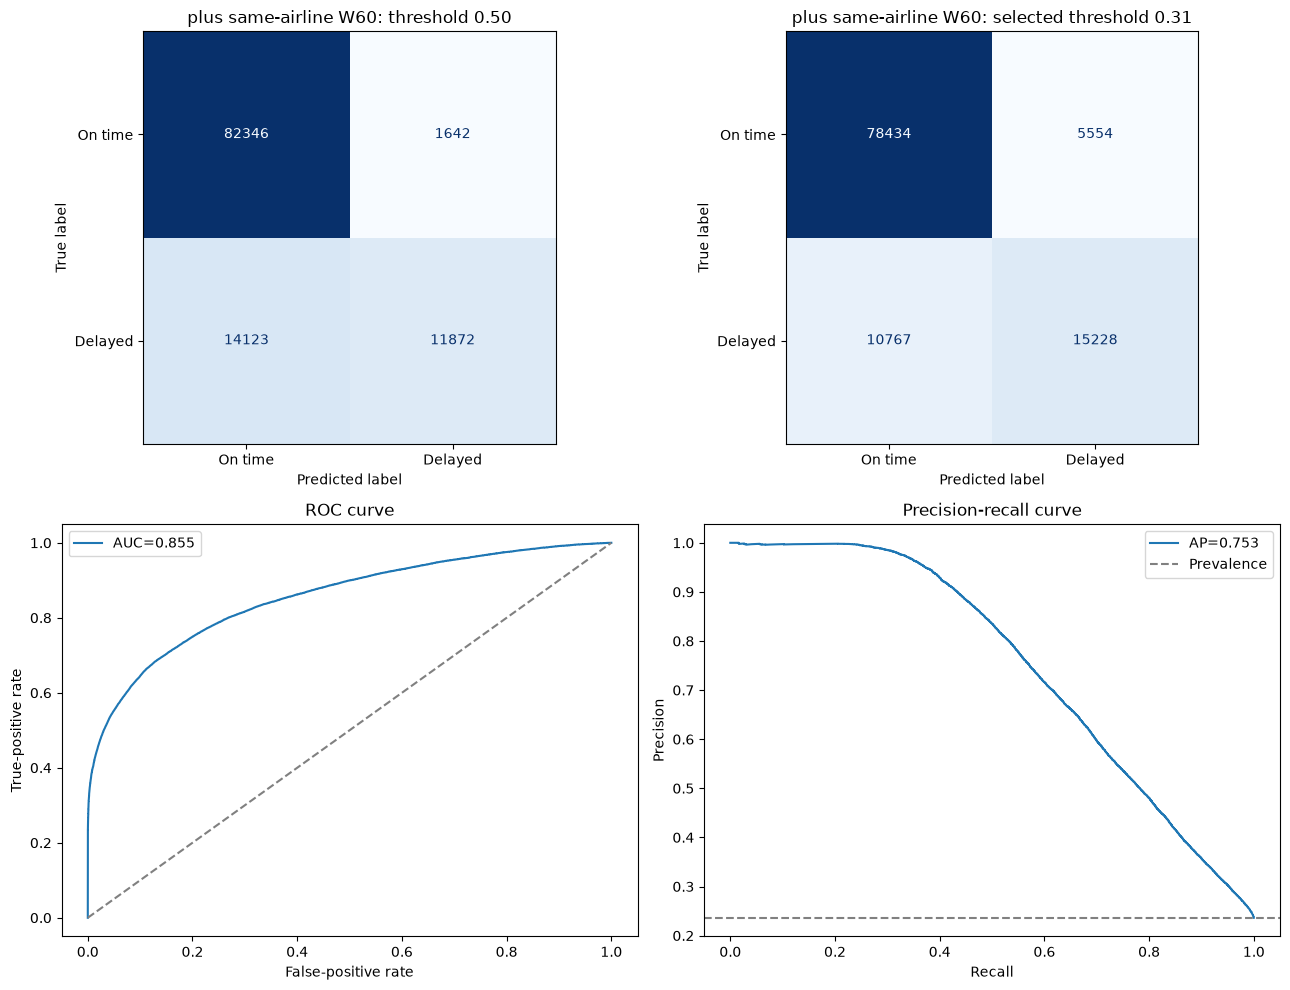

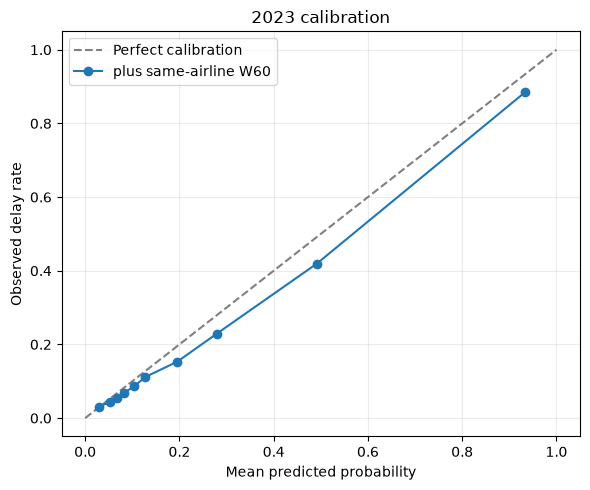

In [11]:
selected_probabilities = validation_probabilities[selected_variant]
selected_threshold = variant_thresholds[selected_variant]
default_predictions = (selected_probabilities >= 0.50).astype(int)
selected_predictions = (selected_probabilities >= selected_threshold).astype(int)
false_positive_rate, true_positive_rate, _ = roc_curve(y_validation, selected_probabilities)
curve_precision, curve_recall, _ = precision_recall_curve(y_validation, selected_probabilities)
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
ConfusionMatrixDisplay.from_predictions(y_validation, default_predictions,
    display_labels=["On time", "Delayed"], cmap="Blues", colorbar=False, ax=axes[0, 0])
axes[0, 0].set_title(f"{selected_variant}: threshold 0.50")
ConfusionMatrixDisplay.from_predictions(y_validation, selected_predictions,
    display_labels=["On time", "Delayed"], cmap="Blues", colorbar=False, ax=axes[0, 1])
axes[0, 1].set_title(f"{selected_variant}: selected threshold {selected_threshold:.2f}")
axes[1, 0].plot(false_positive_rate, true_positive_rate,
                label=f"AUC={roc_auc_score(y_validation, selected_probabilities):.3f}")
axes[1, 0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1, 0].set(xlabel="False-positive rate", ylabel="True-positive rate", title="ROC curve")
axes[1, 0].legend()
axes[1, 1].plot(curve_recall, curve_precision,
                label=f"AP={average_precision_score(y_validation, selected_probabilities):.3f}")
axes[1, 1].axhline(y_validation.mean(), linestyle="--", color="gray", label="Prevalence")
axes[1, 1].set(xlabel="Recall", ylabel="Precision", title="Precision-recall curve")
axes[1, 1].legend(); fig.tight_layout(); plt.show()

predicted, observed = calibration_curve(y_validation, selected_probabilities, n_bins=10, strategy="quantile")
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.plot(predicted, observed, marker="o", label=selected_variant)
ax.set(xlabel="Mean predicted probability", ylabel="Observed delay rate", title="2023 calibration")
ax.legend(); ax.grid(alpha=0.25); plt.tight_layout(); plt.show()


## Inspect both models' importance and publishable values

CatBoost prediction-value-change importance describes fitted use rather than causation. The expanded model's five same-airline fields are displayed even if the 2019 selection rule retains the control.


In [12]:
importance_tables = {}
for variant, model in final_models.items():
    columns = variant_features[variant]
    importance_tables[variant] = (pd.DataFrame({
        "feature": columns, "importance": model.get_feature_importance(),
    }).sort_values("importance", ascending=False).reset_index(drop=True))

selected_model = final_models[selected_variant]
selected_features = variant_features[selected_variant]
feature_importance = importance_tables[selected_variant]
display(feature_importance.head(25))
display(feature_importance[feature_importance["feature"].str.contains("BACKLOG_", regex=False)])

expanded_importance = importance_tables["plus same-airline W60"]
display(expanded_importance[expanded_importance["feature"].isin(SELECTED_AIRLINE_BACKLOG_FEATURES)])

selected_default = evaluation_results.loc[(selected_variant, "Default")]
selected_operating = evaluation_results.loc[(selected_variant, "Training-selected F1")]
control_default = evaluation_results.loc[("CatBoost 02 control", "Default")]
expanded_default = evaluation_results.loc[("plus same-airline W60", "Default")]
result_index = variant_results.set_index("variant")
publishable_summary = pd.Series({
    "CatBoost version": catboost.__version__, "selected variant": selected_variant,
    "selected source fields": len(selected_features), "fixed depth": FIXED_DEPTH,
    "fixed learning rate": FIXED_LEARNING_RATE, "fixed L2 leaf regularization": FIXED_L2_LEAF_REG,
    "fixed trees": FIXED_ITERATIONS,
    "selected training CV AP": result_index.loc[selected_variant, "mean_average_precision"],
    "control training CV AP": result_index.loc["CatBoost 02 control", "mean_average_precision"],
    "expanded training CV AP": result_index.loc["plus same-airline W60", "mean_average_precision"],
    "validation prevalence": y_validation.mean(),
    "selected validation AP": selected_default["average_precision"],
    "control validation AP": control_default["average_precision"],
    "expanded validation AP": expanded_default["average_precision"],
    "selected validation ROC AUC": selected_default["roc_auc"],
    "selected validation Brier": selected_default["brier_score"],
    "selected threshold": variant_thresholds[selected_variant],
    "selected-threshold accuracy": selected_operating["accuracy"],
    "selected-threshold balanced accuracy": selected_operating["balanced_accuracy"],
    "selected-threshold precision": selected_operating["precision"],
    "selected-threshold recall": selected_operating["recall"],
    "selected-threshold F1": selected_operating["f1"],
    "selected-threshold MCC": selected_operating["mcc"],
    "selected AP excluding NOT_ARRIVED": diagnostic_results.loc[(selected_variant, "excluding NOT_ARRIVED"), "average_precision"],
    "comparison seconds": comparison_seconds,
}, name="CatBoost 1A Experiment 04 Appendix D values")
publishable_summary.to_frame()


,feature,importance
0,ROTATION_LOG_ACTUAL_TURN_MINUTES,14.5639
1,ROTATION_ACTUAL_TURN_MINUTES,13.6299
2,ROTATION_INBOUND_ARR_DELAY,6.7206
3,ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF,5.5597
4,ROTATION_STATUS,5.4126
5,ROTATION_SCHEDULED_TURN_MINUTES,5.2039
6,ROTATION_LOG_SCHEDULED_TURN_MINUTES,4.5631
7,CRSDepTime,3.4905
8,Reporting_Airline,3.4422
9,Distance,3.2985


,feature,importance
10,BACKLOG_W60_PENDING_COUNT,3.2675
16,BACKLOG_W60_MEAN_DEP_DELAY,1.9083
18,AIRLINE_BACKLOG_W60_MEAN_DEP_DELAY,1.3604
19,AIRLINE_BACKLOG_W60_PENDING_SHARE,1.3264
22,AIRLINE_BACKLOG_W60_PENDING_COUNT,1.1943
24,BACKLOG_W60_COMPLETED_COUNT,1.0098
33,AIRLINE_BACKLOG_W60_DELAY_RATE,0.2857
36,AIRLINE_BACKLOG_W60_COMPLETED_COUNT,0.2143


,feature,importance
18,AIRLINE_BACKLOG_W60_MEAN_DEP_DELAY,1.3604
19,AIRLINE_BACKLOG_W60_PENDING_SHARE,1.3264
22,AIRLINE_BACKLOG_W60_PENDING_COUNT,1.1943
33,AIRLINE_BACKLOG_W60_DELAY_RATE,0.2857
36,AIRLINE_BACKLOG_W60_COMPLETED_COUNT,0.2143


,CatBoost 1A Experiment 04 Appendix D values
CatBoost version,1.2.10
selected variant,plus same-airline W60
selected source fields,41
fixed depth,6
fixed learning rate,0.0300
fixed L2 leaf regularization,3
fixed trees,683
selected training CV AP,0.7018
control training CV AP,0.7010
expanded training CV AP,0.7018


## Interpretation checklist

1. Do the five same-airline W60 fields improve mean 2019 temporal AP over the exact CatBoost 02 control?
2. Does the training-selected manifest preserve or improve 2023 AP, ROC AUC, and Brier score?
3. Is any difference consistent across chronological folds and rotation subgroups?
4. Which same-airline fields receive meaningful fitted importance after airport-wide backlog and rotation are present?
5. Is the change large enough to replace CatBoost 02, or should the control remain preferred?
6. Preserve the final-tail caveat: both variants remain retrospective upper bounds until timestamped assignment data are available.
